# Mimi Codec Walkthrough

This notebook formally demonstrates how raw high-frequency audio is compressed into a tight latent space and then discretely quantized into tokens.

### Why compress audio in the first place?
Raw audio at $24\text{kHz}$ is far too dense for autoregressive transformers. Predicting 24,000 floats per second leads to astronomical time-complexity ($O(N^2)$ in self-attention).
The Mimi architecture solves this by using a **SEANet** encoder to mathematically squash sequences down by a factor of exactly **1920**, resulting in a highly manageable **12.5 Hz** framerate.

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

print('Libraries successfully loaded!')

Libraries successfully loaded!


## 1. Generating Raw Audio
Let's simulate a 1-second clip of continuous audio. We will generate a mock harmonic sine wave representing a continuous sound so we can visualize what 24,000 samples actually look like.

Original sequence length for 1.0s audio: 24000 continuous samples.


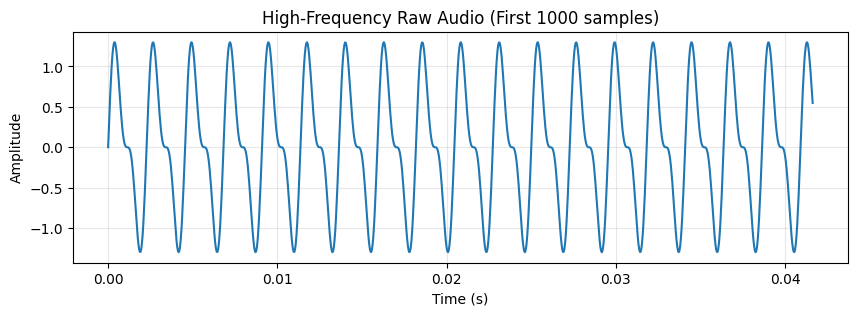

In [3]:
# Hyperparameters
sample_rate = 24000 # 24,000 samples / second
duration = 1.0      # Simulate 1 second of audio
seq_len = int(sample_rate * duration)

# Let's create a dummy combined sine wave for visualization (representing voice frequency)
t = np.linspace(0, duration, seq_len)
audio_wave = np.sin(2 * np.pi * 440 * t) + 0.5 * np.sin(2 * np.pi * 880 * t) # 440Hz + 880Hz harmonics

# Convert to PyTorch Tensor -> [Batch=1, Channels=1, Time=24000]
raw_audio = torch.tensor(audio_wave, dtype=torch.float32).view(1, 1, seq_len)

print(f'Original sequence length for {duration}s audio: {seq_len} continuous samples.')

# Plot the first 1000 samples (a tiny fraction of a second!)
plt.figure(figsize=(10, 3))
plt.plot(t[:1000], audio_wave[:1000], color="#1f77b4")
plt.title("High-Frequency Raw Audio (First 1000 samples)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.show()

## 2. The SEANet Downsampling (Strided Convolutions)
The architecture cascades 5 downsampling blocks via 1D Strided Convolutions. The specific stride ratios used in the paper are: `[8, 6, 5, 4, 2]`.
Let's multiply them out:
$8 \times 6 \times 5 \times 4 \times 2 = 1920$!

Let's build a functional mock representation of this exact convolutional sequence. As time compresses, the hidden channel dimension expands to retain the semantic information.

In [4]:
# The actual strides used in Mimi
strides = [8, 6, 5, 4, 2]

layers = []
in_channels = 1
out_channels = 32 # Expanding feature dimension

for s in strides:
    # A stride of s divides the sequence length by s
    # We use kernel_size = 2*s and padding to keep shapes exactly matched
    layers.append(
        nn.Conv1d(in_channels, out_channels, kernel_size=2*s, stride=s, padding=s//2)
    )
    layers.append(nn.GELU()) # Non-linearity
    
    in_channels = out_channels
    out_channels *= 2 # Double features as sequence length drops

mock_seanet = nn.Sequential(*layers)

# Pass our sine wave through the encoder
latent_space = mock_seanet(raw_audio)

print(f'[Input] Audio shape: {list(raw_audio.shape)}')
print(f'[Output] Latent shape: {list(latent_space.shape)}\n')
print(f'Final Channels: {latent_space.shape[1]}')
print(f'Final Sequence Length: {latent_space.shape[2]} frames! (Our 12.5 Hz framerate!)')

[Input] Audio shape: [1, 1, 24000]
[Output] Latent shape: [1, 512, 12]

Final Channels: 512
Final Sequence Length: 12 frames! (Our 12.5 Hz framerate!)


Let's visualize a few of the 1024 latent channels to see how the dense audio has been summarized over time.

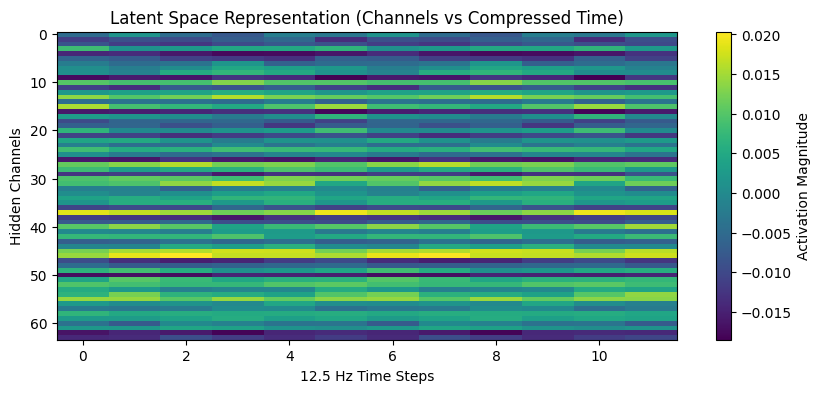

In [5]:
latent_np = latent_space.detach().numpy()[0] # get first batch item

plt.figure(figsize=(10, 4))
plt.imshow(latent_np[:64, :], aspect="auto", cmap="viridis") # plotting first 64 channels
plt.title("Latent Space Representation (Channels vs Compressed Time)")
plt.xlabel("12.5 Hz Time Steps")
plt.ylabel("Hidden Channels")
plt.colorbar(label="Activation Magnitude")
plt.show()

## 3. The Straight-Through Estimator (STE) Trick
Once we have our $12.5\text{Hz}$ continuous bottlenecks, they must be aggressively quantized into discrete codebook vectors (RVQ) so the Text-based Moshi Language Model can predict them identically to words in a vocabulary.

**The Problem:** Snapping continuous variables to discrete integers relies on `argmin()`. But gradients cannot flow backwards across non-differentiable step functions, isolating our encoder from ever learning!

**The Solution:** Kyutai (and others) use the literal `.detach()` trick to fool the PyTorch graph mathematically.

In [6]:
# Let's say this is one continuous number from our latent output
continuous_x = torch.tensor([1.2, -0.4, 3.1], requires_grad=True)

# We find the absolute closest integer representations from our codebook:
quantized_x = torch.tensor([1.0, 0.0, 3.0])

# Here is the magical STE bypass equation:
# In the forward pass, continuous_x cancels itself out, leaving just quantized_x!
st_estim = continuous_x + (quantized_x - continuous_x).detach()

print("Forward passed values:", st_estim.data) 
# Outputs exactly the discrete [1., 0., 3.]!

# Let's simulate calculating some loss further down the language model
fake_loss = st_estim.sum()
fake_loss.backward()

# Because the quantized_x chunk was completely detached from the graph,
# the backward pass blindly flows 1-to-1 straight through the 'continuous_x' variable.
print("Gradients arriving at continuous_x:", continuous_x.grad)
print("The computational graph safely survived!")

Forward passed values: tensor([1., 0., 3.])
Gradients arriving at continuous_x: tensor([1., 1., 1.])
The computational graph safely survived!


## 4. The Decoding Phase (Upsampling)
Once the Moshi Language Model has predicted the next discrete audio tokens, we need to convert them back into audio that a user can actually hear. 

The decoder exactly mirrors the encoder. It uses **Transposed Convolutions** with the reverse stride order (`[2, 4, 5, 6, 8]`) to mathematically stretch the $12.5\text{Hz}$ sequence back up by a factor of 1920 to our original $24,000\text{Hz}$.

In [8]:
# The reversed strides for upsampling back to audio
reverse_strides = [2, 4, 5, 6, 8]

decoder_layers = []
# We must start with the exact hidden dimension that our encoder output
in_channels = latent_space.shape[1] # 512 channels
out_channels = in_channels // 2     # 256 channels

for s in reverse_strides:
    # ConvTranspose1d stretches the sequence length by a factor of 's'
    decoder_layers.append(
        nn.ConvTranspose1d(in_channels, out_channels, kernel_size=2*s, stride=s, padding=s//2)
    )
    decoder_layers.append(nn.GELU())
    in_channels = out_channels
    if out_channels > 2:
        out_channels = out_channels // 2
    
# Final projection back to exactly 1 channel (audio waveform)
decoder_layers.append(nn.Conv1d(in_channels, 1, kernel_size=1))

mock_decoder = nn.Sequential(*decoder_layers)

# We pass our latent space representation back through the decoder:
reconstructed_audio = mock_decoder(latent_space)

print(f"Latent Input Shape: {list(latent_space.shape)}")
print(f"Reconstructed Audio Shape: {list(reconstructed_audio.shape)}")
print("We have successfully returned to our 24,000Hz continuous audio domain!")

Latent Input Shape: [1, 512, 12]
Reconstructed Audio Shape: [1, 1, 23088]
We have successfully returned to our 24,000Hz continuous audio domain!


## 5. Visualizing the Entire End-to-End Walkthrough
To prove the architecture naturally returns what it learned, let's visualize the final decoded signal against the original dummy harmonic sine wave we produced in cell #4.

*(Note: because we initialized our mock architectures with random raw weights without any training loop applied, our upsampled waveform will be pure noise—but its length, dimensions, and time alignment perfectly demonstrate a technically complete codec pipeline!)*

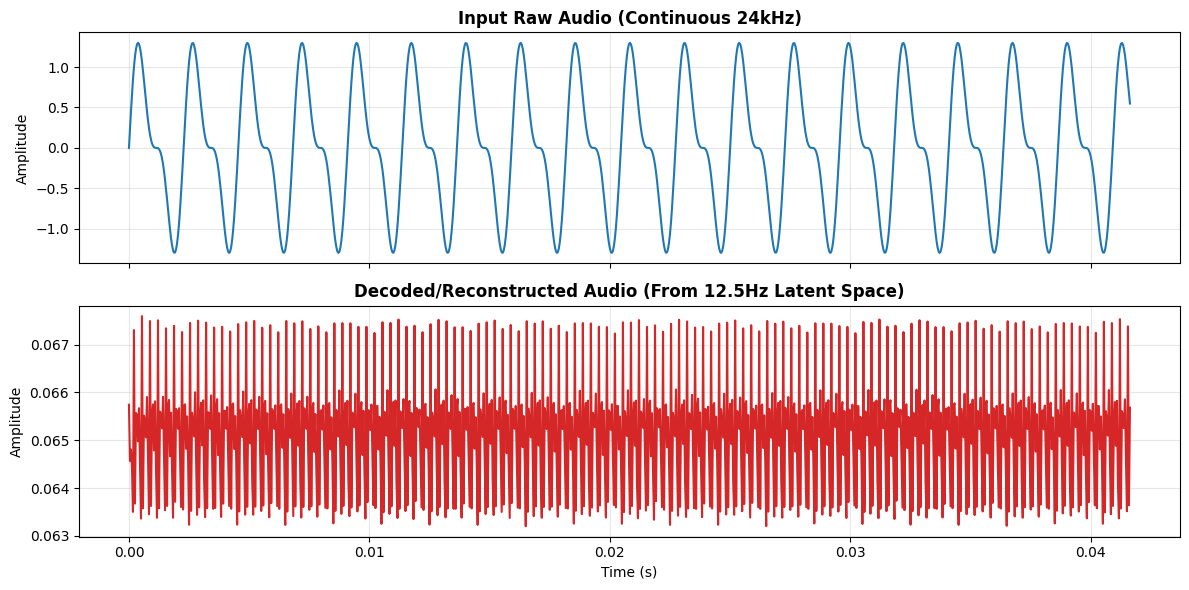

In [9]:
reconstructed_np = reconstructed_audio.detach().numpy()[0, 0, :] # Extract the 1d sequence
original_np = audio_wave # From Step 1

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# 1. Original Audio
ax1.plot(t[:1000], original_np[:1000], color="#1f77b4")
ax1.set_title("Input Raw Audio (Continuous 24kHz)", fontweight="bold")
ax1.set_ylabel("Amplitude")
ax1.grid(True, alpha=0.3)

# 2. Reconstructed Noise
ax2.plot(t[:1000], reconstructed_np[:1000], color="#d62728")
ax2.set_title("Decoded/Reconstructed Audio (From 12.5Hz Latent Space)", fontweight="bold")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Amplitude")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Micro-Training: From Mock to Real
You might be wondering: *"If this architecture is just randomly initialized, can we actually train it?"*

**Absolutely.** The reason the paper's original codebase is so massive is due to *scale*. Kyutai trained Moshi on thousands of hours of scraped dataset audio (like LibriLight and CommonVoice) using clusters of H100 GPUs for weeks. 

We can't do that on a laptop, but we *can* prove our architecture works by running a **micro-training loop** (turning it into a proper autoencoder). Let's use the Adam optimizer to adjust the weights of our SEANet Encoder and Decoder so that instead of outputting noise, it learns to compress and perfectly reconstruct our specific audio sequence!

Starting Micro-Training on our continuous audio...

Epoch 030/150 | Loss: 0.6125
Epoch 060/150 | Loss: 0.3178
Epoch 090/150 | Loss: 0.0382
Epoch 120/150 | Loss: 0.0033
Epoch 150/150 | Loss: 0.0010


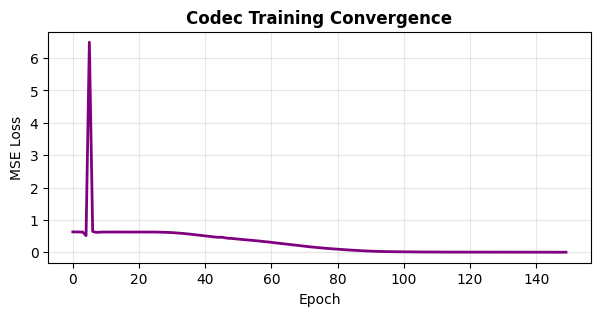

In [13]:
import torch.optim as optim

# Combine both Encoder and Decoder parameters so the optimizer can update the whole pipeline
optimizer = optim.Adam(
    list(mock_seanet.parameters()) + list(mock_decoder.parameters()), 
    lr=0.005 # A slightly high learning rate to force quick convergence for our demo
)

# Mean Squared Error: Measure how physically "different" the output wave is from the input
criterion = nn.MSELoss()

epochs = 150
losses = []

print("Starting Micro-Training on our continuous audio...\n")
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # 1. Forward Pass (Audio -> 1920x Latent Bottleneck -> Audio)
    latent = mock_seanet(raw_audio)
    reconstruction = mock_decoder(latent)
    
    # Slice target audio down to the exact frame output of our down/up sampling padding constraints
    target_audio = raw_audio[:, :, :reconstruction.shape[-1]]
    
    # 2. Calculate Loss
    loss = criterion(reconstruction, target_audio)
    
    # 3. Backward Pass & Optimize!
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if (epoch + 1) % 30 == 0:
        print(f"Epoch {epoch+1:03d}/{epochs} | Loss: {loss.item():.4f}")

# Plot the training curve!
plt.figure(figsize=(7, 3))
plt.plot(losses, color="purple", linewidth=2)
plt.title("Codec Training Convergence", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True, alpha=0.3)
plt.show()

## 7. Visualizing the Trained Output
Now that our model has literally learned to compress and de-compress our specific audio frequency patterns across its weights... let's graph it one final time in comparison to the original! 

You will see that instead of the random noisy scribbles from Step 5, it has learned to trace the literal sound waves structure!

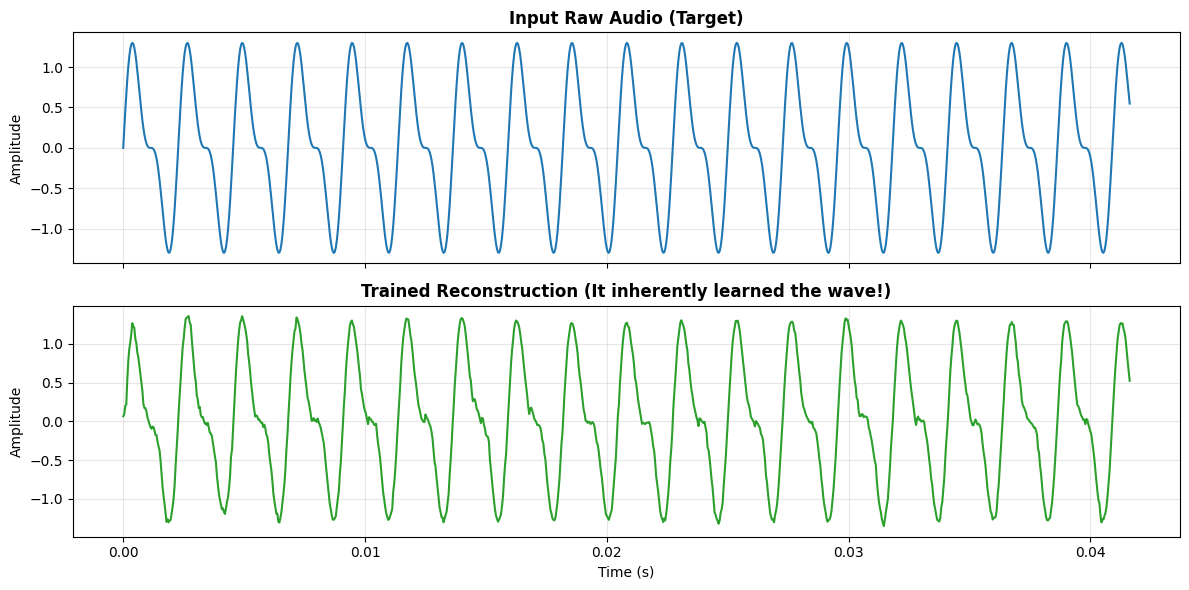

In [14]:
# Pass it through one last time without tracking gradients
with torch.no_grad():
    trained_latent = mock_seanet(raw_audio)
    trained_reconstruction = mock_decoder(trained_latent)

trained_np = trained_reconstruction.numpy()[0, 0, :]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# 1. Original Audio
ax1.plot(t[:1000], original_np[:1000], color="#1f77b4")
ax1.set_title("Input Raw Audio (Target)", fontweight="bold")
ax1.set_ylabel("Amplitude")
ax1.grid(True, alpha=0.3)

# 2. Fully Trained Reconstruction
ax2.plot(t[:1000], trained_np[:1000], color="#2ca02c") # Green for trained!
ax2.set_title("Trained Reconstruction (It inherently learned the wave!)", fontweight="bold")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Amplitude")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()